In [1]:
# pip install scikit-learn

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
print(f"샘플 수: {data.data.shape[0]:,}")
print(f"피처 수: {data.data.shape[1]}")
print(f"타겟: {data.target_names}")
print(f"\n피처 목록:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1}. {name}")

샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude


In [2]:
# pip install torch torchvision torchaudio

import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")        # (20640, 8)
print(f"타겟 크기: {y.shape}")        # (20640,)
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")
print(f"\n피처별 통계:")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}  평균: {X[:, i].mean():10.2f}  표준편차: {X[:, i].std():10.2f}")

피처 크기: (20640, 8)
타겟 크기: (20640,)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)

피처별 통계:
  MedInc        평균:       3.87  표준편차:       1.90
  HouseAge      평균:      28.64  표준편차:      12.59
  AveRooms      평균:       5.43  표준편차:       2.47
  AveBedrms     평균:       1.10  표준편차:       0.47
  Population    평균:    1425.48  표준편차:    1132.43
  AveOccup      평균:       3.07  표준편차:      10.39
  Latitude      평균:      35.63  표준편차:       2.14
  Longitude     평균:    -119.57  표준편차:       2.00


In [3]:
# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # *your code* — test_size와 random_state 설정
)

print(f"학습 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")

학습 데이터: 16,512개
테스트 데이터: 4,128개


In [4]:
# 학습 데이터의 평균/표준편차 계산 (테스트 데이터에는 학습 데이터의 통계를 사용)
train_mean = X_train.mean(axis=0)  # *your code* — 축(axis) 설정
train_std = X_train.std(axis=0)    # *your code* — 축(axis) 설정

print("피처별 평균:", np.round(train_mean, 2))
print("피처별 표준편차:", np.round(train_std, 2))

피처별 평균: [ 3.88000e+00  2.86100e+01  5.44000e+00  1.10000e+00  1.42645e+03
  3.10000e+00  3.56400e+01 -1.19580e+02]
피처별 표준편차: [1.90000e+00 1.26000e+01 2.39000e+00 4.30000e-01 1.13702e+03 1.15800e+01
 2.14000e+00 2.01000e+00]


In [5]:
# 정규화 적용
X_train_norm = (X_train - train_mean) / train_std  # *your code* — 정규화 공식
X_test_norm = (X_test - train_mean) / train_std     # 테스트에도 학습 데이터의 통계 사용

print(f"정규화 후 학습 데이터 평균: {X_train_norm.mean(axis=0).round(4)}")  # 거의 0
print(f"정규화 후 학습 데이터 표준편차: {X_train_norm.std(axis=0).round(4)}")  # 거의 1

정규화 후 학습 데이터 평균: [-0. -0.  0. -0. -0. -0.  0. -0.]
정규화 후 학습 데이터 표준편차: [1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# 텐서 변환
X_train_tensor = torch.FloatTensor(X_train_norm)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # *your code* — (N,) → (N,1)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"X_train 텐서: {X_train_tensor.shape}")  # torch.Size([16512, 8])
print(f"y_train 텐서: {y_train_tensor.shape}")  # torch.Size([16512, 1])

X_train 텐서: torch.Size([16512, 8])
y_train 텐서: torch.Size([16512, 1])


In [7]:
class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),   # *your code* — 입력 차원 → 64
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),           # *your code* — 32 → 1 (회귀 출력)
        )

    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(f"모델 구조:\n{model}")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

모델 구조:
HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 2,689


In [8]:
# 학습 설정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()                                          # *your code* — 회귀이므로 MSELoss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)         # *your code* — Adam 옵티마이저

EPOCHS = 50

In [9]:
# 학습 루프
model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)          # *your code* — 순전파
        loss = criterion(predictions, y_batch) # *your code* — 손실 계산
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg_loss:.4f}")

Epoch  10/50 — Loss: 0.5417
Epoch  20/50 — Loss: 0.4674
Epoch  30/50 — Loss: 0.4299
Epoch  40/50 — Loss: 0.4012
Epoch  50/50 — Loss: 0.3942


In [13]:
# 테스트 평가
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)

    # MAE (Mean Absolute Error) 계산
    mae = torch.abs(test_preds - y_test_tensor).mean().item()

print(f"테스트 MSE:  {test_loss.item():.4f}")
print(f"테스트 MAE:  {mae:.4f} ($100,000 단위)")
print(f"테스트 MAE:  ${mae * 100000:,.0f} (실제 금액)")

테스트 MSE:  0.3325
테스트 MAE:  0.3908 ($100,000 단위)
테스트 MAE:  $39,081 (실제 금액)


In [14]:
import os
# os.makedirs("models", exist_ok=True)

# 모델 가중치 저장
torch.save(model.state_dict(), "../models/housing_model.pth")  # *your code* — state_dict 저장
print(f"✅ 모델 저장: models/housing_model.pth ({os.path.getsize('../models/housing_model.pth')/1024:.1f} KB)")

# 전처리 파라미터 저장 (배포 시 필수!)
preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": feature_names,
}

import json
with open("../models/housing_preprocessing.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)

print(f"✅ 전처리 파라미터 저장: models/housing_preprocessing.json")

✅ 모델 저장: models/housing_model.pth (13.3 KB)
✅ 전처리 파라미터 저장: models/housing_preprocessing.json


In [15]:
# 모듈 테스트
import sys

# 1. 현재 노트북 파일이 있는 위치를 정확히 파악해서 경로에 추가
current_path = os.path.abspath(".")
if current_path not in sys.path:
    sys.path.insert(0, current_path)

# 2. 확인 사격: 실제로 app 폴더가 이 경로에 있는지 출력
print(f"현재 탐색 경로: {current_path}")
print(f"현재 폴더 내 항목: {os.listdir(current_path)}")

# 3. 이제 임포트 시도
try:
    from app.housing_model import HousingPredictor
    print("✅ 성공: HousingPredictor를 불러왔습니다.")
except ModuleNotFoundError:
    # 만약 위에서도 실패한다면, 한 단계 상위 폴더도 뒤져보도록 설정
    parent_path = os.path.dirname(current_path)
    sys.path.insert(0, parent_path)
    from app.housing_model import HousingPredictor
    print("✅ 성공: 상위 경로 참조로 불러왔습니다.")

from app.housing_model import HousingPredictor

predictor = HousingPredictor(
    model_path="../models/housing_model.pth",
    preprocessing_path="../models/housing_preprocessing.json",
)

# 테스트 데이터의 첫 번째 샘플로 테스트
sample_features = {name: float(X_test[0, i]) for i, name in enumerate(feature_names)}
print(f"입력 피처: {sample_features}")

result = predictor.predict(sample_features)
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"실제 가격: ${int(y_test[0] * 100000):,}")

현재 탐색 경로: c:\Users\lang0\aiffel_project\MLOps\MLOps01\notebooks
현재 폴더 내 항목: ['day5_project1.ipynb']
✅ 성공: HousingPredictor를 불러왔습니다.
입력 피처: {'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}
예측 가격: $78,753
실제 가격: $47,700


In [ ]:
# uvicorn app.housing_api:app --host 0.0.0.0 --port 8000 --reload → 서버 실행해서 swagger 테스트
# http://localhost:8000/docs

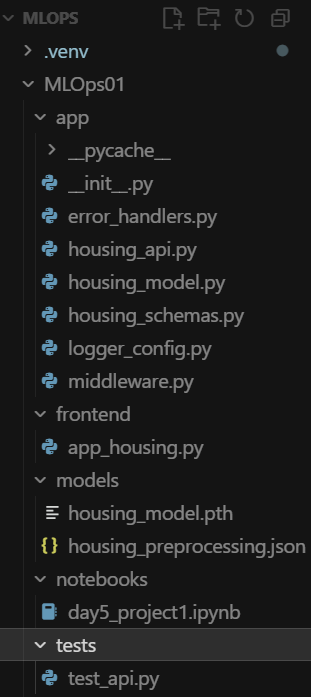

In [19]:
from IPython.display import Image
Image(filename='폴더구조.png', width=200)

```
--- 정상 요청 테스트 ---
상태 코드: 200
예측 가격: $175,795

--- 에러 테스트: 필드 누락 ---
필드 누락 응답 코드: 422
============================================================
   Housing API 통합 테스트 시작
   Target: http://localhost:8000
============================================================

[테스트 1] 단일 데이터 추론
상태 코드: 200
예측 가격: $175,795

[테스트 2] 다양한 시나리오 결과
케이스                       예측 가격
----------------------------------------
저소득 지역       $     102,911
고소득 지역       $     483,060
평균적 주택       $     175,795

============================================================
   모든 테스트 완료
============================================================

[테스트 2] 에러 상황
  필드 누락      → HTTP 422
  위도 범위 초과  → HTTP 422
  소득 음수      → HTTP 422
  잘못된 포맷    → HTTP 422

[테스트 3] 동시 요청 (8개)
  요청 #1: 2.047초 (HTTP 200)
  요청 #2: 2.05초 (HTTP 200)
  요청 #3: 2.049초 (HTTP 200)
  요청 #4: 2.048초 (HTTP 200)
  요청 #5: 2.043초 (HTTP 200)
  요청 #6: 2.044초 (HTTP 200)
  요청 #7: 2.044초 (HTTP 200)
  요청 #8: 2.04초 (HTTP 200)
  전체: 2.06초

[테스트 4] 헬스체크
  상태: {'status': 'healthy', 'model': 'California Housing'}

============================================================
  테스트 결과 종합
============================================================
  ✅ 정상 요청: 다양한 입력에서 합리적인 가격 반환
  ✅ 에러 처리: 잘못된 입력에 422/400 반환, 서버 안 죽음
  ✅ 동시 처리: 8개 동시 요청 정상 처리
  ✅ 헬스체크: 서버 상태 정상
```

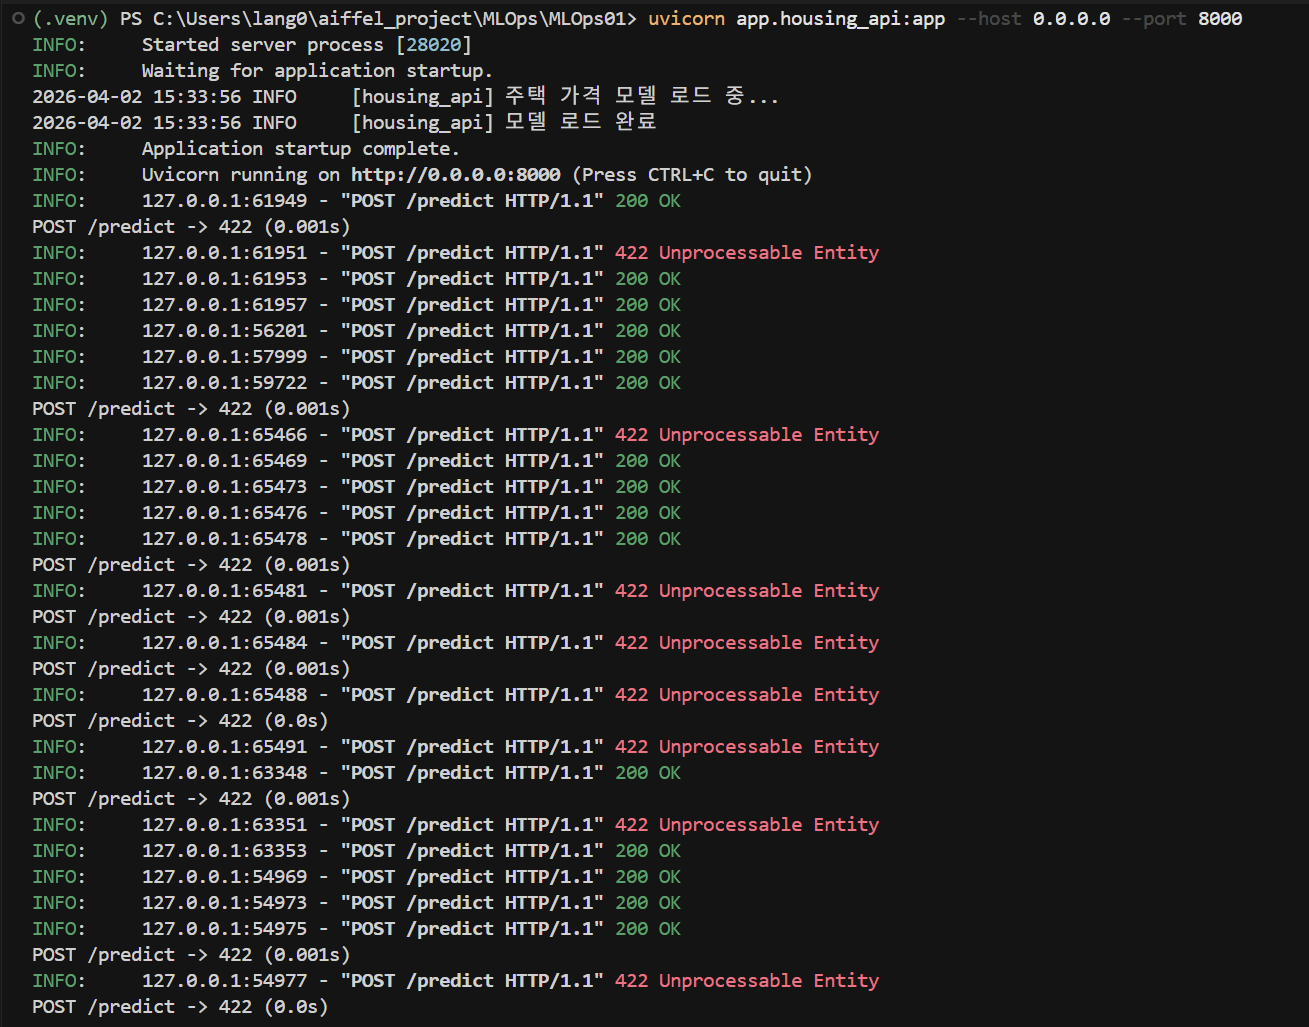

In [24]:
Image(filename='터미널1.png', width=800)

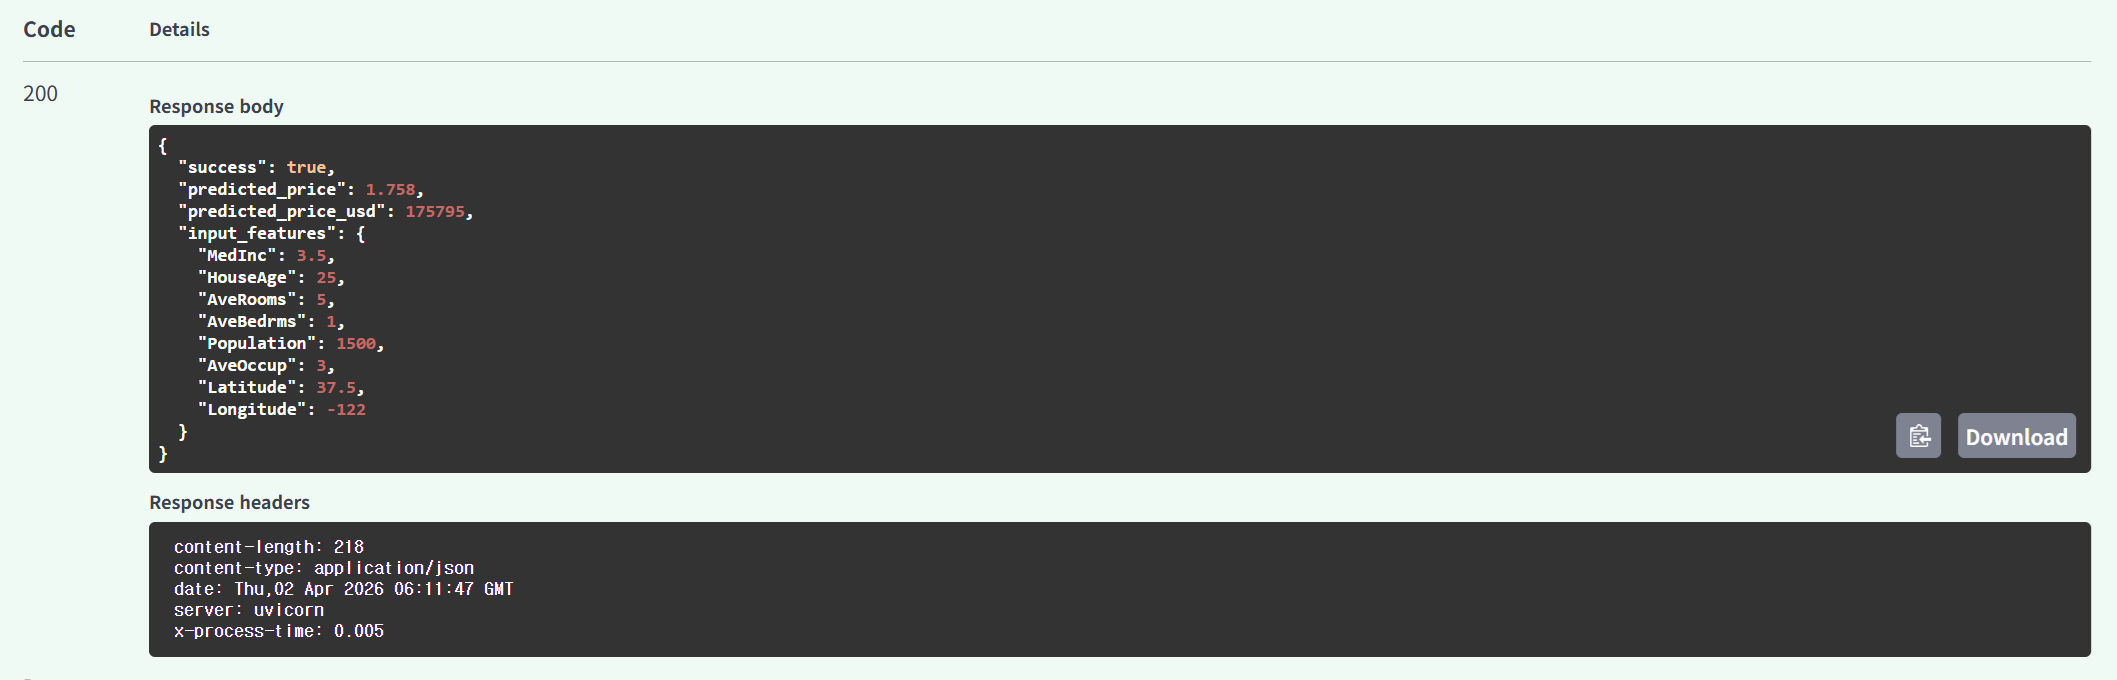

In [26]:
Image(filename='스웨거ui.png', width=900)

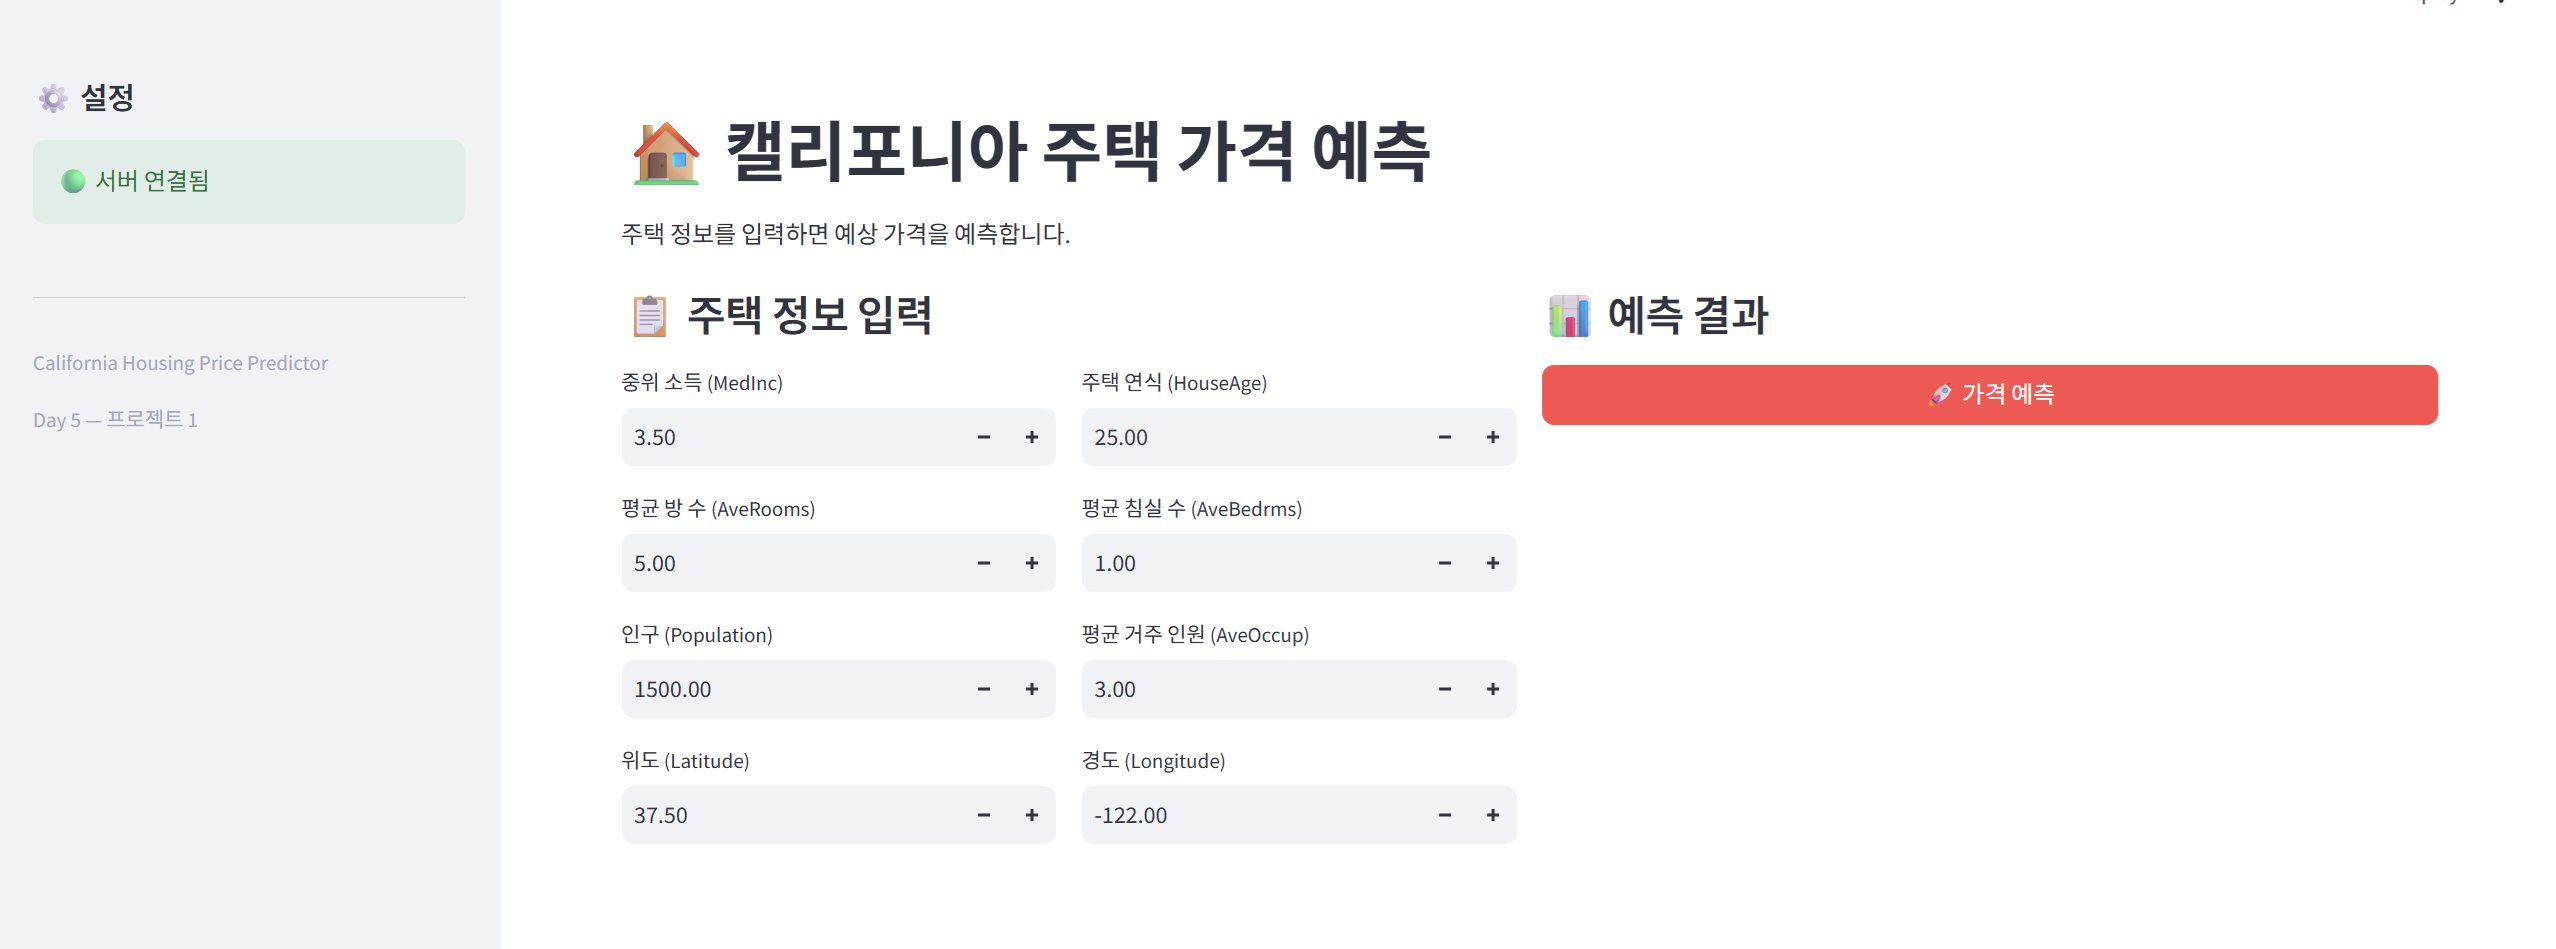

In [27]:
Image(filename='프론트엔드.png', width=900)